<a href="https://colab.research.google.com/github/sreekanthTa/BreedPredictionDL/blob/main/AgeAndGenderDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# !unzip -n "/content/drive/MyDrive/DeepLearning/AgeAndGender/archive (2).zip" -d "/content/drive/MyDrive/DeepLearning/AgeAndGender"

In [6]:
import os

dataset_path = "/content/drive/MyDrive/DeepLearning/AgeAndGender/UTKFace"

images= os.listdir(dataset_path)
len(images)

23708

In [7]:
age = []
gender = []
images_path = []

for image in images[:1000]:
  split_path = image.split("_")
  images_path.append(dataset_path + "/"+ image)
  age.append(split_path[0])
  gender.append(split_path[1])
len(age), len(gender), len(images_path)
# images_path

(1000, 1000, 1000)

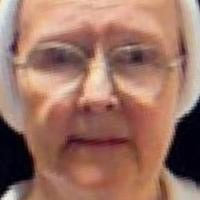

In [8]:
import random
from IPython.display import Image


num_of_images = 1

random_image_index = random.sample(images_path, num_of_images)
Image(random_image_index[0])

In [9]:
import pandas as pd;

df = pd.DataFrame()
df["images"] = images_path
df["gender"] = gender
df["age"] = age

# Convert 'age' and 'gender' columns to numeric type
df['age'] = pd.to_numeric(df['age'])
df['gender'] = pd.to_numeric(df['gender'])

df.head(5)

,images,gender,age
0,/content/drive/MyDrive/DeepLearning/AgeAndGend...,0,75
1,/content/drive/MyDrive/DeepLearning/AgeAndGend...,0,86
2,/content/drive/MyDrive/DeepLearning/AgeAndGend...,1,79
3,/content/drive/MyDrive/DeepLearning/AgeAndGend...,0,76
4,/content/drive/MyDrive/DeepLearning/AgeAndGend...,1,8


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
    )



In [29]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


train_df, val_df = train_test_split(df, test_size=0.2, random_state=43)

scaler = MinMaxScaler()

# Fit the scaler on the 'age' column of the training data
scaler.fit(train_df[['age']])

# Transform the 'age' column in both training and validation data
train_df['age'] = scaler.transform(train_df[['age']])
val_df['age'] = scaler.transform(val_df[['age']])


len(train_df), len(val_df)

(800, 200)

In [30]:
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=dataset_path,
    x_col="images",
    y_col=["gender", "age"],
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=dataset_path,
    x_col="images",
    y_col=["gender", "age"],
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=True
)


Found 800 validated image filenames.
Found 200 validated image filenames.


In [31]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [32]:
import tensorflow as tf

model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Flatten(), # Added a Flatten layer to transition between the Conv2D and Dense layers
    tf.keras.layers.Dense(2)
])

model_1.compile(
    optimizer="Adam",
    loss="mse",
    metrics=["mae"]
)

history_1 = model_1.fit(
    train_generator,
    epochs=10,
    validation_data= val_generator,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 509ms/step - loss: 0.6922 - mae: 0.6504 - val_loss: 0.2284 - val_mae: 0.4385
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 485ms/step - loss: 0.2086 - mae: 0.4231 - val_loss: 0.1942 - val_mae: 0.4140
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 474ms/step - loss: 0.1977 - mae: 0.4167 - val_loss: 0.1895 - val_mae: 0.4105
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 482ms/step - loss: 0.1907 - mae: 0.4065 - val_loss: 0.1796 - val_mae: 0.3778
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 483ms/step - loss: 0.1815 - mae: 0.3866 - val_loss: 0.1912 - val_mae: 0.4079
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 479ms/step - loss: 0.1890 - mae: 0.3974 - val_loss: 0.1599 - val_mae: 0.3516
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 483ms/step - loss: 0.1763 - mae: 0.3773 - val_loss: 0.1641 - val_mae: 0.3497
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 484ms/step - loss: 0.1762 - mae: 0.3706 - val_loss: 0.1652 - val_mae: 0.3687
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 487ms/

<Axes: >

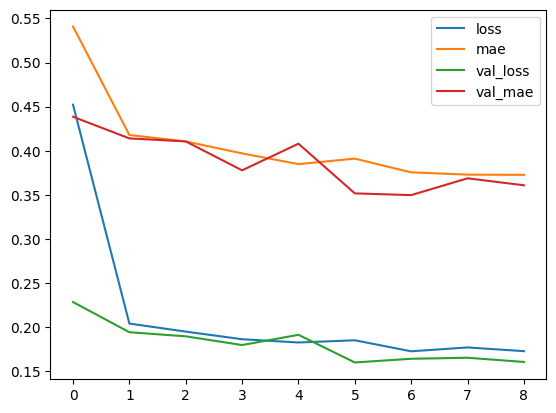

In [33]:
pd.DataFrame(history_1.history).plot()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.6371973 0.7307338]]
Original Gender: 1
Original Age: 85
Gender Prediction: 0.6371973
Age Prediction: [[74.22751069]]


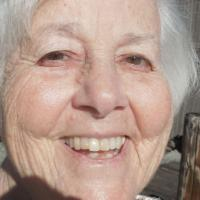

In [106]:
from tensorflow.keras.preprocessing import image
import numpy as np

num_of_images = 1

random_image_index = random.sample(images_path, num_of_images)
random_image_index[0]
Image(random_image_index[0])
img = image.load_img(random_image_index[0], target_size=(224, 224))

img_array = image.img_to_array(img)
# print(img_array)
img_array = np.expand_dims(img_array, axis=0)

img_array = img_array/255.0

# Make prediction using the model
prediction = model_1.predict(img_array)
print(prediction)
# Extract gender and age predictions
gender_prediction = prediction[0][0]  # Assuming gender is the first element in the output
age_prediction = prediction[0][1]  # Assuming age is the second element in the output

actual_age =  scaler.inverse_transform([[age_prediction]])


import os

img_path =  random_image_index[0]

# Extract filename from path
filename = os.path.basename(img_path)

# Split filename to get age and gender
parts = filename.split('_')
age = int(parts[0])
gender = int(parts[1])

print("Original Gender:", gender)
print("Original Age:", age)


print("Gender Prediction:", gender_prediction)
print("Age Prediction:", actual_age)
Image(random_image_index[0])

In [34]:
early_stopping_2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [48]:
import tensorflow as tf

model_2 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Dropout(0.25), # Dropout after Conv layer
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Dropout(0.25), # Dropout after Conv layer
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Dropout(0.25), # Dropout after Conv layer
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Dropout(0.25), # Dropout after Conv layer
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout after Dense layer
    tf.keras.layers.Dense(2, activation='sigmoid')
])

model_2.compile(
    optimizer="Adam",
    loss="mse",
    metrics=["mae", "accuracy"]
)

history_2 = model_2.fit(
    train_generator,
    epochs=10,
    validation_data= val_generator,
    callbacks=[early_stopping_2]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 522ms/step - accuracy: 0.4594 - loss: 0.3442 - mae: 0.4596 - val_accuracy: 0.5250 - val_loss: 0.1985 - val_mae: 0.4358
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 486ms/step - accuracy: 0.4809 - loss: 0.2007 - mae: 0.4371 - val_accuracy: 0.5250 - val_loss: 0.1984 - val_mae: 0.4355
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 486ms/step - accuracy: 0.5423 - loss: 0.2001 - mae: 0.4360 - val_accuracy: 0.5550 - val_loss: 0.1980 - val_mae: 0.4347
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 477ms/step - accuracy: 0.5721 - loss: 0.1950 - mae: 0.4238 - val_accuracy: 0.6250 - val_loss: 0.1934 - val_mae: 0.4295
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 479ms/step - accuracy: 0.5720 - loss: 0.1905 - mae: 0.4142 - val_accuracy: 0.6400 - val_loss: 0.1878 - val_mae: 0.4215
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 479ms/step - accuracy: 0.5703 - loss: 0.1870 - mae: 0.4066 - val_accuracy: 0.5900 - val_loss: 0.1867 - val_mae: 0.4178
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━

<Axes: >

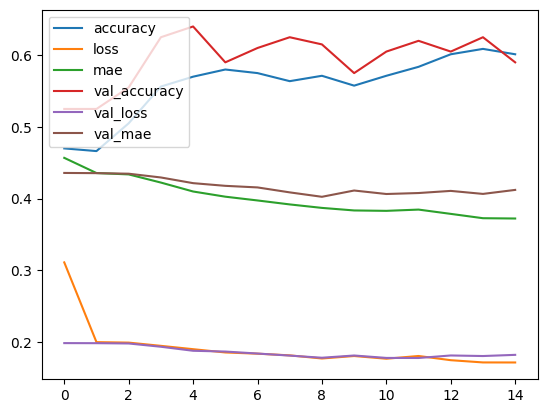

In [49]:

pd.DataFrame(history_2.history).plot()

'/content/drive/MyDrive/DeepLearning/AgeAndGender/UTKFace/7_0_3_20170119144311624.jpg.chip.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.48001778 0.4060617 ]]
Original Gender: 0
Original Age: 9
Gender Prediction: 0.48001778
Age Prediction: [[44.35767722]]


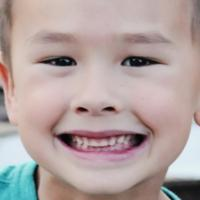

In [89]:
from tensorflow.keras.preprocessing import image
import numpy as np

num_of_images = 1

random_image_index = random.sample(images_path, num_of_images)
random_image_index[0]
Image(random_image_index[0])
img = image.load_img(random_image_index[0], target_size=(224, 224))

img_array = image.img_to_array(img)
# print(img_array)
img_array = np.expand_dims(img_array, axis=0)

img_array = img_array/255.0

# Make prediction using the model
prediction = model_2.predict(img_array)
print(prediction)
# Extract gender and age predictions
gender_prediction = prediction[0][0]  # Assuming gender is the first element in the output
age_prediction = prediction[0][1]  # Assuming age is the second element in the output

actual_age =  scaler.inverse_transform([[age_prediction]])


import os

img_path =  random_image_index[0]

# Extract filename from path
filename = os.path.basename(img_path)

# Split filename to get age and gender
parts = filename.split('_')
age = int(parts[0])
gender = int(parts[1])

print("Original Gender:", gender)
print("Original Age:", age)


print("Gender Prediction:", gender_prediction)
print("Age Prediction:", actual_age)
Image(random_image_index[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
[[0.46868622 0.5812585 ]]
Gender Prediction: 0.46868622
Age Prediction: [[60.47577977]]


Original Age: 100
Original Gender: 0


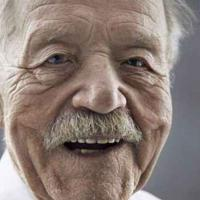